In [1]:
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# new filters June 20th
def dataset_filter(dataset):
    # Filtering based on multiple conditions
    condition = (
        (dataset["ACCL:LI21:1:L1S_S_PV"] < 0)
        & (dataset["ACCL:LI21:1:L1S_S_AV"] > 100)
        & (dataset["ACCL:LI22:1:ADES"] > 3000)
        & (dataset["ACCL:LI22:1:ADES"] < 5400)
        & (dataset["XRMS on VCC"] > 300)
        & (dataset["XRMS on VCC"] < 350)
        & (dataset["YRMS on VCC"] > 250)
        & (dataset["YRMS on VCC"] < 350)
        & (dataset["hxr_pulse_intensity"] > 0.02)
        & (dataset["hxr_pulse_intensity"] < 4.5)
        & (dataset["HXR electron energy [GeV]"] > 8)
        & (dataset["HXR photon energy [eV]"] > 7000)
    )
    return dataset[condition]

In [3]:
# get testing samples from dataset
test_set = pd.read_pickle("./data2/hxr_archiver_2025-04_cleaned.pkl")
test_set = dataset_filter(test_set)
test_set.index[:2], test_set.index[-2:]

(DatetimeIndex(['2025-04-06 06:41:09.810108160-07:00', '2025-04-06 06:41:10.768165632-07:00'], dtype='datetime64[ns, US/Pacific]', name='datetime', freq=None),
 DatetimeIndex(['2025-04-24 23:59:58.771899136-07:00', '2025-04-24 23:59:59.721960960-07:00'], dtype='datetime64[ns, US/Pacific]', name='datetime', freq=None))

In [4]:
def split_timestamps(
    timestamps: pd.Index,
    window_size: int,
    min_window_size: int = 2,
):
    n = len(timestamps)
    chunks: List[pd.Index] = []
    for start in range(0, n, window_size):
        end = min(start + window_size, n)
        chunks.append(timestamps[start:end])

    if len(chunks) > 1 and len(chunks[-1]) < min_window_size:
        chunks[-2] = chunks[-2].append(chunks[-1])
        chunks.pop()

    return chunks

chunks = split_timestamps(test_set.index, 3)
chunks[:2]

[DatetimeIndex(['2025-04-06 06:41:09.810108160-07:00',
                '2025-04-06 06:41:10.768165632-07:00',
                '2025-04-06 06:41:11.726222848-07:00'],
               dtype='datetime64[ns, US/Pacific]', name='datetime', freq=None),
 DatetimeIndex(['2025-04-06 06:41:12.684148992-07:00',
                '2025-04-06 06:41:13.642206464-07:00',
                '2025-04-06 06:41:14.592006144-07:00'],
               dtype='datetime64[ns, US/Pacific]', name='datetime', freq=None)]

# Load the original model

In [5]:
# Define the fractions of the total number of rows for the selected validation set
selected_ranges = [(0, 1)]

selected_validation_set = pd.DataFrame()
for start_fraction, end_fraction in selected_ranges:
    start_index = int(start_fraction * len(test_set))
    end_index = int(end_fraction * len(test_set))
    subset = test_set.iloc[start_index:end_index]
    selected_validation_set = pd.concat([selected_validation_set, subset])

In [6]:
# Load model
loaded_model_path = "model/final_lcls_fel_model.pt"
loaded_input_scaler_path = "model/lcls_fel_input_scaler.pt"
loaded_output_scaler_path = "model/lcls_fel_output_scaler.pt"

model = torch.load(loaded_model_path, weights_only=False)
input_scaler = torch.load(loaded_input_scaler_path, weights_only=False)
output_scaler = torch.load(loaded_output_scaler_path, weights_only=False)

with open("model/feature_config.yml", "r") as fh:
    yml = yaml.safe_load(fh)
input_cols = list(yml["input_variables"].keys())
output_cols = list(yml["output_variables"].keys())

/Users/95j/_penv/torch-penv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
input_data = torch.tensor(selected_validation_set[input_cols].values)

In [8]:
X_raw = torch.tensor(selected_validation_set[input_cols].values, dtype=torch.float32)
y_raw = torch.tensor(selected_validation_set[output_cols].values, dtype=torch.float32)

In [10]:
# Scale input
X_scaled = input_scaler.transform(X_raw)
y_scaled = output_scaler.transform(y_raw)  # SCALED MEASUREMENTS

# Predict
model_output = model(X_scaled)

# Unscale (keep as torch tensor!)
model_output_unscaled = output_scaler.untransform(model_output)

# Ensure y_raw is a torch tensor
y_true = torch.as_tensor(y_raw, dtype=model_output_unscaled.dtype)

# Match shape
y_true = y_true.view_as(model_output_unscaled)

# Compute MSE
mse = torch.mean((model_output_unscaled - y_true) ** 2).item()

print("MSE (original units):", mse)

MSE (original units): 0.9684737324714661


In [11]:
# Unscale the output
model_output_unscaled = output_scaler.untransform(model_output).detach().numpy()

# Plot a fixed window of the original data and the initial predictions

In [12]:
start_date = pd.Timestamp("2025-04-18 12:00")
end_date = pd.Timestamp("2025-04-20 12:00")

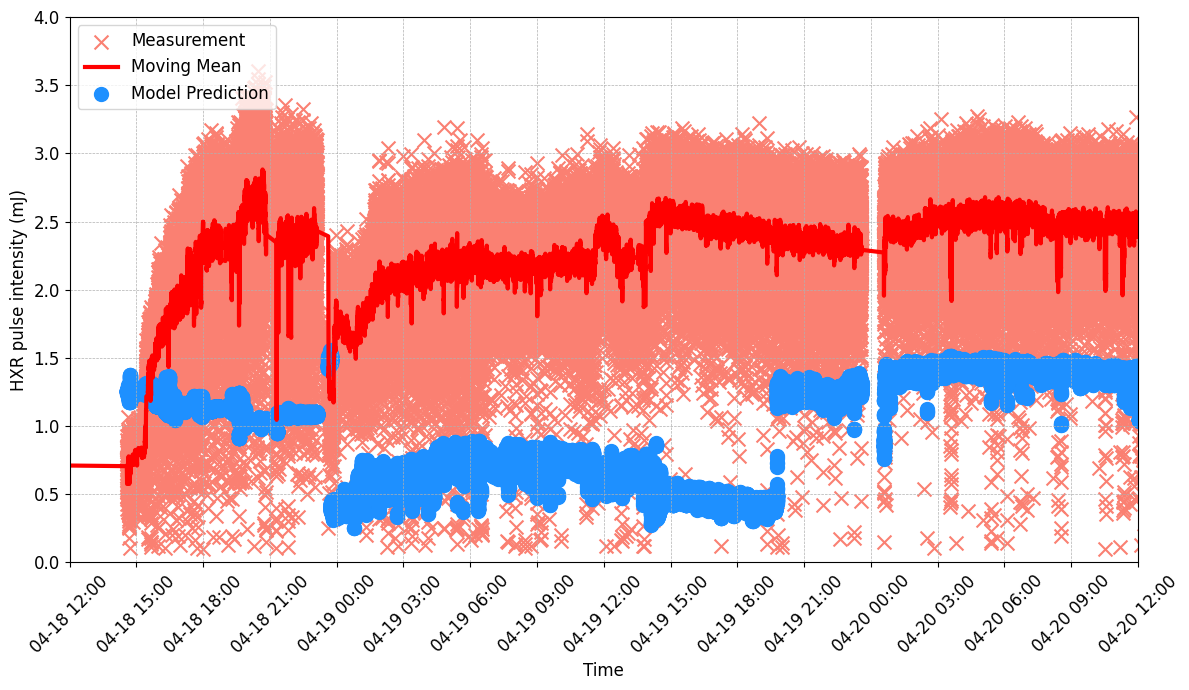

In [13]:
# Plot the unscaled data without drift
date_format = mdates.DateFormatter("%m-%d %H:%M")

fontsize = 12
plt.figure(figsize=(12, 7))
window_size = 50

ground_truth = selected_validation_set["hxr_pulse_intensity"]
moving_avg = ground_truth.rolling(window=window_size).mean()

plt.scatter(
    selected_validation_set.index,
    ground_truth,
    label="Measurement",
    color="salmon",
    marker="x",
    s=100,
)
plt.plot(
    selected_validation_set.index,
    moving_avg,
    label="Moving Mean",
    color="red",
    linewidth=3,
)
plt.scatter(
    selected_validation_set.index,
    model_output_unscaled,
    label="Model Prediction",
    color="dodgerblue",
    marker="o",
    s=100,
)
plt.xlabel("Time", fontsize=fontsize)
plt.ylabel("HXR pulse intensity (mJ)", fontsize=fontsize)

# plt.xlim(selected_validation_set.index.min(), selected_validation_set.index.max())
plt.xlim(start_date, end_date)

# Date formatting and auto ticks based on zoom level
ax = plt.gca()

# ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(date_format)

plt.ylim([0, 4])
plt.legend(fontsize=12, loc="upper left")
plt.tick_params(labelsize=fontsize)
plt.tick_params(axis="x", rotation=45)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# Plot the drift area for the same window

In [14]:
# ADWIN detector
start_shade = pd.Timestamp("2025-04-19 17:55")
end_shade = pd.Timestamp("2025-04-19 19:24")
# PageHinkleyDetector
#start_shade = pd.Timestamp("2025-05-17 04:44")
#end_shade = pd.Timestamp("2025-05-17 06:33")

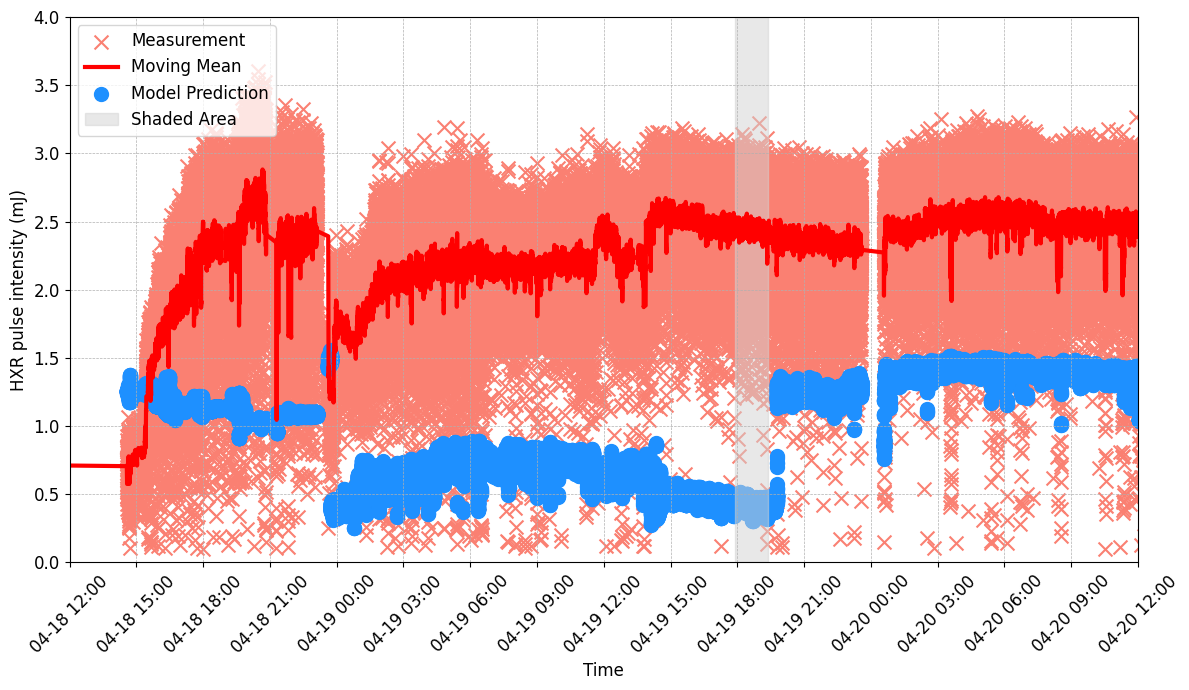

In [15]:
# Plot the unscaled data
date_format = mdates.DateFormatter("%m-%d %H:%M")

fontsize = 12
plt.figure(figsize=(12, 7))
window_size = 50

ground_truth = selected_validation_set["hxr_pulse_intensity"]
moving_avg = ground_truth.rolling(window=window_size).mean()

plt.scatter(
    selected_validation_set.index,
    ground_truth,
    label="Measurement",
    color="salmon",
    marker="x",
    s=100,
)
plt.plot(
    selected_validation_set.index,
    moving_avg,
    label="Moving Mean",
    color="red",
    linewidth=3,
)
plt.scatter(
    selected_validation_set.index,
    model_output_unscaled,
    label="Model Prediction",
    color="dodgerblue",
    marker="o",
    s=100,
)
plt.xlabel("Time", fontsize=fontsize)
plt.ylabel("HXR pulse intensity (mJ)", fontsize=fontsize)

# plt.xlim(selected_validation_set.index.min(), selected_validation_set.index.max())
plt.xlim(start_date, end_date)


# Date formatting and auto ticks based on zoom level
ax = plt.gca()

# ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(date_format)

# Shading the area between at drift location
plt.fill_betweenx(
    y=[0, 4],
    x1=start_shade,
    x2=end_shade,
    color="lightgray",
    alpha=0.5,
    label="Shaded Area",
)

plt.ylim([0, 4])
plt.legend(fontsize=12, loc="upper left")
plt.tick_params(labelsize=fontsize)
plt.tick_params(axis="x", rotation=45)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

Using ADWIN detector drifts occur in the following timeframes:
- drift 1 [2025-04-19 17:55:51.153006080-07:00 → 2025-04-19 19:24:11.960220672-07:00]
- drift 2 [2025-05-17 04:44:59.832188416-07:00 → 2025-05-17 06:33:21.784591104-07:00]
- drift 3 [2025-09-07 22:15:48.181196544-07:00 → 2025-09-07 23:35:23.898307072-07:00]
- drift 4 [2025-11-12 19:28:18.762950912-08:00 → 2025-11-12 20:50:03.736012544-08:00]

# Load the model after doing continual learning

In [16]:
import torch
import torch.nn as nn

loaded_model_path = "../../output/slac/drift_adaptation_4.pt"

def build_model(input_dim: int = 115) -> nn.Module:
    # Must match the architecture used in training
    return nn.Sequential(
        nn.Linear(input_dim, 512),
        nn.ELU(),
        nn.Linear(512, 256),
        nn.ELU(),
        nn.Linear(256, 128),
        nn.ELU(),
        nn.Dropout(p=0.05),
        nn.Linear(128, 64),
        nn.ELU(),
        nn.Dropout(p=0.05),
        nn.Linear(64, 16),
        nn.ELU(),
        nn.Dropout(p=0.05),
        nn.Linear(16, 16),
        nn.ELU(),
        nn.Linear(16, 1),
    )

device = "cpu"

model = build_model(input_dim=115).to(device)
state = torch.load(loaded_model_path, map_location=device, weights_only=False)

# If your keys are like 'net.0.weight' but the model expects '0.weight', strip 'net.'
if all(k.startswith("net.") for k in state.keys()):
    state = {k.replace("net.", "", 1): v for k, v in state.items()}

model.load_state_dict(state, strict=True)
model.eval()

Sequential(
  (0): Linear(in_features=115, out_features=512, bias=True)
  (1): ELU(alpha=1.0)
  (2): Linear(in_features=512, out_features=256, bias=True)
  (3): ELU(alpha=1.0)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): ELU(alpha=1.0)
  (6): Dropout(p=0.05, inplace=False)
  (7): Linear(in_features=128, out_features=64, bias=True)
  (8): ELU(alpha=1.0)
  (9): Dropout(p=0.05, inplace=False)
  (10): Linear(in_features=64, out_features=16, bias=True)
  (11): ELU(alpha=1.0)
  (12): Dropout(p=0.05, inplace=False)
  (13): Linear(in_features=16, out_features=16, bias=True)
  (14): ELU(alpha=1.0)
  (15): Linear(in_features=16, out_features=1, bias=True)
)

In [20]:
input_data = torch.tensor(selected_validation_set[input_cols].values)
X_raw = torch.tensor(selected_validation_set[input_cols].values, dtype=torch.float32)
y_raw = torch.tensor(selected_validation_set[output_cols].values, dtype=torch.float32)
# Scale input
X_scaled = input_scaler.transform(X_raw)
y_scaled = output_scaler.transform(y_raw)  # SCALED MEASUREMENTS

# Predict
model_output = model(X_scaled)

# Scale input
X_scaled = input_scaler.transform(X_raw)
y_scaled = output_scaler.transform(y_raw)  # SCALED MEASUREMENTS

# Predict
model_output = model(X_scaled)

# Unscale (keep as torch tensor!)
model_output_unscaled = output_scaler.untransform(model_output)

# Ensure y_raw is a torch tensor
y_true = torch.as_tensor(y_raw, dtype=model_output_unscaled.dtype)

# Match shape
y_true = y_true.view_as(model_output_unscaled)

# Compute MSE
mse = torch.mean((model_output_unscaled - y_true) ** 2).item()

print("MSE after CL:", mse)

MSE after CL: 0.5408313274383545


In [18]:
# Unscale the output
model_output_unscaled = output_scaler.untransform(model_output).detach().numpy()

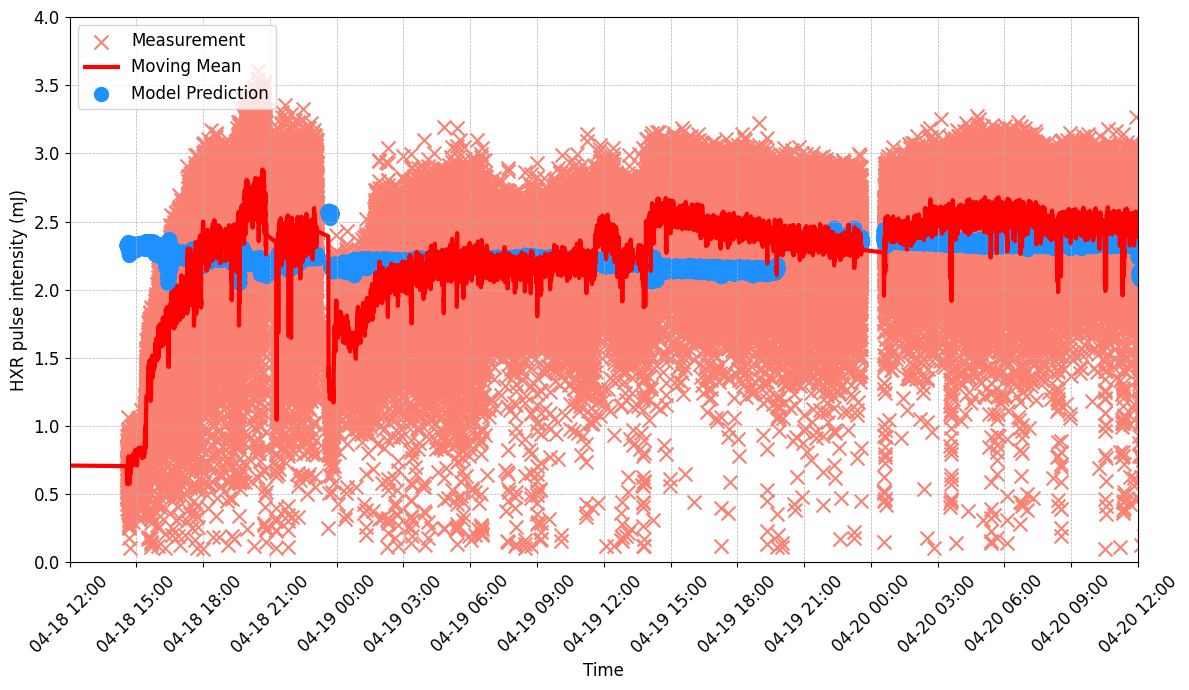

In [19]:
# Plot the unscaled data without drift
date_format = mdates.DateFormatter("%m-%d %H:%M")

fontsize = 12
plt.figure(figsize=(12, 7))
window_size = 50

ground_truth = selected_validation_set["hxr_pulse_intensity"]
moving_avg = ground_truth.rolling(window=window_size).mean()

plt.scatter(
    selected_validation_set.index,
    ground_truth,
    label="Measurement",
    color="salmon",
    marker="x",
    s=100,
)
plt.plot(
    selected_validation_set.index,
    moving_avg,
    label="Moving Mean",
    color="red",
    linewidth=3,
)
plt.scatter(
    selected_validation_set.index,
    model_output_unscaled,
    label="Model Prediction",
    color="dodgerblue",
    marker="o",
    s=100,
)
plt.xlabel("Time", fontsize=fontsize)
plt.ylabel("HXR pulse intensity (mJ)", fontsize=fontsize)

# plt.xlim(selected_validation_set.index.min(), selected_validation_set.index.max())
plt.xlim(start_date, end_date)

# Date formatting and auto ticks based on zoom level
ax = plt.gca()

# ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(date_format)

plt.ylim([0, 4])
plt.legend(fontsize=12, loc="upper left")
plt.tick_params(labelsize=fontsize)
plt.tick_params(axis="x", rotation=45)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()